<a href="https://colab.research.google.com/github/Ashishpathak78/DL_practice/blob/main/DL_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

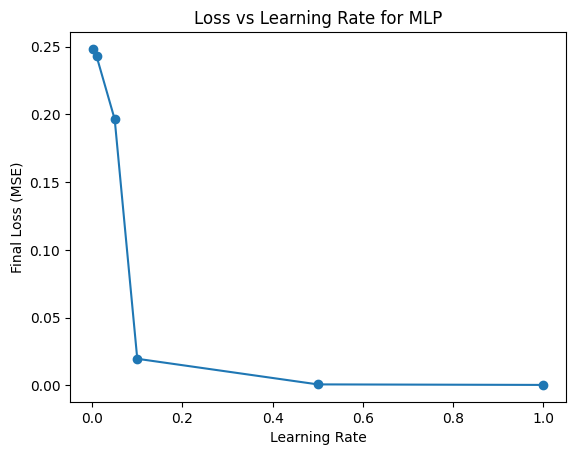

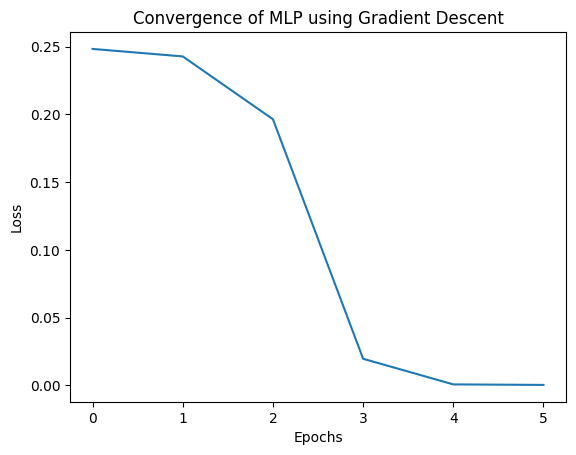

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


class MLP:
    def __init__(self, learning_rate):
        self.lr = learning_rate
        self.w1 = np.random.randn(2, 2)
        self.b1 = np.random.randn(1, 2)
        self.w2 = np.random.randn(2, 1)
        self.b2 = np.random.randn(1, 1)

    def forward(self, X):
        self.h = sigmoid(np.dot(X, self.w1) + self.b1)
        self.out = sigmoid(np.dot(self.h, self.w2) + self.b2)
        return self.out

    def backward(self, X, y):
        error = y - self.out
        loss = np.mean(error ** 2)

        d_out = error * sigmoid_derivative(self.out)
        d_h = d_out.dot(self.w2.T) * sigmoid_derivative(self.h)

        self.w2 += self.h.T.dot(d_out) * self.lr
        self.b2 += np.sum(d_out, axis=0, keepdims=True) * self.lr
        self.w1 += X.T.dot(d_h) * self.lr
        self.b1 += np.sum(d_h, axis=0, keepdims=True) * self.lr

        return loss

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []
epochs = 5000

for lr in learning_rates:
    model = MLP(lr)
    for _ in range(epochs):
        model.forward(X)
        loss = model.backward(X, y)
    final_losses.append(loss)

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Loss vs Learning Rate for MLP")
plt.show()



plt.plot(final_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of MLP using Gradient Descent")
plt.show()



In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load IRIS dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]

print("Learning Rate vs Accuracy")
print("---------------------------")

for lr in learning_rates:
    perceptron = Perceptron(
        eta0=lr,          # learning rate
        max_iter=1000,
        random_state=0
    )

    perceptron.fit(X_train, y_train)
    y_pred = perceptron.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Learning rate: {lr}, Accuracy: {acc:.4f}")
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load IRIS dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]

print("Learning Rate vs Accuracy")
print("---------------------------")

for lr in learning_rates:
    perceptron = Perceptron(
        eta0=lr,          # learning rate
        max_iter=1000,
        random_state=0
    )

    perceptron.fit(X_train, y_train)
    y_pred = perceptron.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Learning rate: {lr}, Accuracy: {acc:.4f}")


Learning Rate vs Accuracy
---------------------------
Learning rate: 0.0001, Accuracy: 0.6444
Learning rate: 0.001, Accuracy: 0.6222
Learning rate: 0.01, Accuracy: 0.8000
Learning rate: 0.1, Accuracy: 0.8000
Learning rate: 1, Accuracy: 0.8000
Learning Rate vs Accuracy
---------------------------
Learning rate: 0.0001, Accuracy: 0.6444
Learning rate: 0.001, Accuracy: 0.6222
Learning rate: 0.01, Accuracy: 0.8000
Learning rate: 0.1, Accuracy: 0.8000
Learning rate: 1, Accuracy: 0.8000


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Parameters to explore
learning_rates = [0.001, 0.01, 0.1]
iterations = [200, 500, 1000]

print("Learning Rate | Max Iter | Test Accuracy")
print("-----------------------------------------")

for lr in learning_rates:
    for it in iterations:
        mlp = MLPClassifier(
            hidden_layer_sizes=(50,),
            learning_rate_init=lr,
            max_iter=it,
            random_state=1
        )
        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"{lr:<13} {it:<9} {acc:.4f}")


Learning Rate | Max Iter | Test Accuracy
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.001         200       0.9912
0.001         500       0.9825
0.001         1000      0.9825
0.01          200       0.9737
0.01          500       0.9737
0.01          1000      0.9737
0.1           200       0.9737
0.1           500       0.9737
0.1           1000      0.9737


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Normalize pixel values
X = X / 255.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=20,
    random_state=42,
    verbose=True
)

# Train the model
mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Iteration 1, loss = 0.39286260
Iteration 2, loss = 0.15239755
Iteration 3, loss = 0.10608706
Iteration 4, loss = 0.08038778
Iteration 5, loss = 0.06403363
Iteration 6, loss = 0.05088564
Iteration 7, loss = 0.04088828
Iteration 8, loss = 0.03441392
Iteration 9, loss = 0.02911492
Iteration 10, loss = 0.02490929
Iteration 11, loss = 0.01988026
Iteration 12, loss = 0.01600589
Iteration 13, loss = 0.01437448
Iteration 14, loss = 0.01047791
Iteration 15, loss = 0.01086533
Iteration 16, loss = 0.00985182
Iteration 17, loss = 0.00891190
Iteration 18, loss = 0.00688038
Iteration 19, loss = 0.00833706
Iteration 20, loss = 0.00814995
Test Accuracy: 0.9724285714285714
Confusion Matrix:
 [[1327    1    5    0    1    1    5    0    3    0]
 [   0 1584    5    2    2    0    1    4    2    0]
 [   0    4 1360    1    2    1    5    1    5    1]
 [   2    1   19 1392    0   11    0    1    3    4]
 [   1    2    9    0 1265    1    2    1    2   12]
 [   2    1    0   12    1 1234   12    3    7    1

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras.utils import to_categorical


# Load MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Preprocessing

X_train = X_train.reshape(60000, 784) / 255.0
X_test = X_test.reshape(10000, 784) / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


# Model builder function

def build_mlp(optimizer):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Dictionary to store results

results = {}


# (a) Batch Gradient Descent

model_bgd = build_mlp(SGD(learning_rate=0.01))
model_bgd.fit(X_train, y_train, epochs=10, batch_size=60000, verbose=0)
results["Batch GD"] = model_bgd.evaluate(X_test, y_test, verbose=0)[1]


# (b) Stochastic Gradient Descent

model_sgd = build_mlp(SGD(learning_rate=0.01))
model_sgd.fit(X_train, y_train, epochs=10, batch_size=1, verbose=0)
results["Stochastic GD"] = model_sgd.evaluate(X_test, y_test, verbose=0)[1]


# (c) Mini-Batch Gradient Descent

model_minibatch = build_mlp(SGD(learning_rate=0.01))
model_minibatch.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
results["Mini-batch GD"] = model_minibatch.evaluate(X_test, y_test, verbose=0)[1]


# (d) SGD with Momentum

model_momentum = build_mlp(SGD(learning_rate=0.01, momentum=0.9))
model_momentum.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
results["Momentum GD"] = model_momentum.evaluate(X_test, y_test, verbose=0)[1]


# (e) SGD with Nesterov Momentum

model_nesterov = build_mlp(
    SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
)
model_nesterov.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
results["Nesterov GD"] = model_nesterov.evaluate(X_test, y_test, verbose=0)[1]


# (f) Adagrad

model_adagrad = build_mlp(Adagrad(learning_rate=0.01))
model_adagrad.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
results["Adagrad"] = model_adagrad.evaluate(X_test, y_test, verbose=0)[1]


# (g) RMSprop

model_rmsprop = build_mlp(RMSprop(learning_rate=0.001))
model_rmsprop.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
results["RMSprop"] = model_rmsprop.evaluate(X_test, y_test, verbose=0)[1]


# (h) Adam

model_adam = build_mlp(Adam(learning_rate=0.001))
model_adam.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
results["Adam"] = model_adam.evaluate(X_test, y_test, verbose=0)[1]


# Print comparison results

print("\nTest Accuracy Comparison:")
for optimizer, acc in results.items():
    print(f"{optimizer:20s}: {acc:.4f}")



Test Accuracy Comparison:
Batch GD            : 0.1043
Stochastic GD       : 0.9689
Mini-batch GD       : 0.9634
Momentum GD         : 0.9757
Nesterov GD         : 0.9796
Adagrad             : 0.9705
RMSprop             : 0.9780
Adam                : 0.9789
